## Анализ звука

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchaudio.transforms
from torch.utils.data import DataLoader, Dataset

from transformers import ASTModel, ASTFeatureExtractor

import librosa
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
from scipy.spatial.distance import pdist, squareform

from datasets import load_dataset
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

In [2]:
def show_device_info():
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f'Using device: {device}')
    if device.type == 'cuda':
        print(torch.cuda.get_device_name(0))

In [3]:
show_device_info()

Using device: cuda
NVIDIA GeForce RTX 2060


In [4]:
def load_huggingface_dataset_1(tag):
    dataset = load_dataset(tag)
    X_train = []
    y_train = []
    sr_train = []
    X_test = []
    y_test = []
    sr_test = []
    le = LabelEncoder()
    for sample in dataset['train']:
        sr_train.append(sample['audio']['sampling_rate'])
        X_train.append(sample['audio']['array'])
        y_train.append(sample['nombreCientifico'])
    for sample in dataset['test']:
        sr_test.append(sample['audio']['sampling_rate'])
        X_test.append(sample['audio']['array'])
        y_test.append(sample['nombreCientifico'])
    return X_train, le.fit_transform(y_train), sr_train, X_test, le.fit_transform(y_test), sr_test

In [18]:
bird_tag = "capa2000/binary-classifier-birdnet"

In [53]:
def load_bird_dataset():
    return load_huggingface_dataset_1(bird_tag)

In [5]:
def extract_mfcc(wav, sr=44100, target_sr=16000, n_mfcc=20):
    if sr != target_sr:
        wav = librosa.resample(wav, orig_sr=sr, target_sr=target_sr)
        sr = target_sr
    mfcc = librosa.feature.mfcc(y=wav, sr=sr, n_mfcc=n_mfcc)
    mean_mfcc = np.mean(mfcc, axis=1)
    std_mfcc = np.std(mfcc, axis=1)
    return np.concatenate([mean_mfcc, std_mfcc])

In [6]:
def extract_mfccs(X, srs, target_sr=16000, n_mfcc=20):
    return np.array([extract_mfcc(wav, sr=sr, target_sr=target_sr, n_mfcc=n_mfcc) for wav, sr in zip(X, srs)])

In [7]:
def visualize_tsne(X, y, n_components=2, perplexity=50, name='MFCC features'):
    tsne = TSNE(n_components=n_components, perplexity=perplexity)
    X_tsne = tsne.fit_transform(X)
    plt.figure(figsize=(8,6))
    sns.scatterplot(x=X_tsne[:,0], y=X_tsne[:,1], hue=y, palette='Set1')
    plt.title(f't-SNE visualization of {name}')
    plt.show()
    return tsne

In [8]:
def visualize_pca(X, y, n_components=2, name='MFCC features'):
    pca = PCA(n_components=n_components)
    X_pca = pca.fit_transform(X)
    plt.figure(figsize=(8,6))
    sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=y, palette='Set1')
    plt.title(f'PCA visualization of {name} (explained variance: {pca.explained_variance_ratio_.sum()})')
    plt.show()
    return pca

In [9]:
def simple_fit_predict(X_train, y_train, X_test, y_test):
    models = {
            'SVM (RBF)': SVC(kernel='rbf', gamma='scale'),
            'SVM (linear)': SVC(kernel='linear', C=1.0),
            'SVM (poly)': SVC(kernel='poly', degree=3, gamma='scale', coef0=0.0, C=1.0),
            'Random Forest': RandomForestClassifier(n_estimators=1000),
            'Logistic Regression': LogisticRegression(max_iter=10000)
        }
    for name, clf in models.items():
        clf.fit(X_train, y_train)
        y_pred = clf.predict(X_test)
        acc = accuracy_score(y_test, y_pred)
        print(f'{name}: accuracy = {acc:.4f}')

In [10]:
class HuggingfaceDatasetAnalyze:
    def __init__(self, tag, target_sr=16000, n_mfcc=20, load_huggingface_dataset=load_huggingface_dataset_1):
        self.X_train, self.y_train, self.sr_train, self.X_test, self.y_test, self.sr_test = load_huggingface_dataset(tag)
        self.X_train_mfcc = extract_mfccs(self.X_train, srs=self.sr_train, target_sr=target_sr, n_mfcc=n_mfcc)
        self.X_test_mfcc = extract_mfccs(self.X_test, srs=self.sr_test, target_sr=target_sr, n_mfcc=n_mfcc)
        self.y_all = np.concatenate([self.y_train, self.y_test])

    def tsne(self, n_components=2, perplexity=50):
        X_all_mfcc = np.vstack([self.X_train_mfcc, self.X_test_mfcc])
        return visualize_tsne(X_all_mfcc, self.y_all, n_components=n_components, perplexity=perplexity)

    def pca(self, n_components=2):
        X_all_mfcc = np.vstack([self.X_train_mfcc, self.X_test_mfcc])
        return visualize_pca(X_all_mfcc, self.y_all, n_components=n_components)

    def simple_fit_predict(self):
        simple_fit_predict(self.X_train_mfcc, self.y_train, self.X_test_mfcc, self.y_test)

In [19]:
analyze = HuggingfaceDatasetAnalyze(bird_tag)

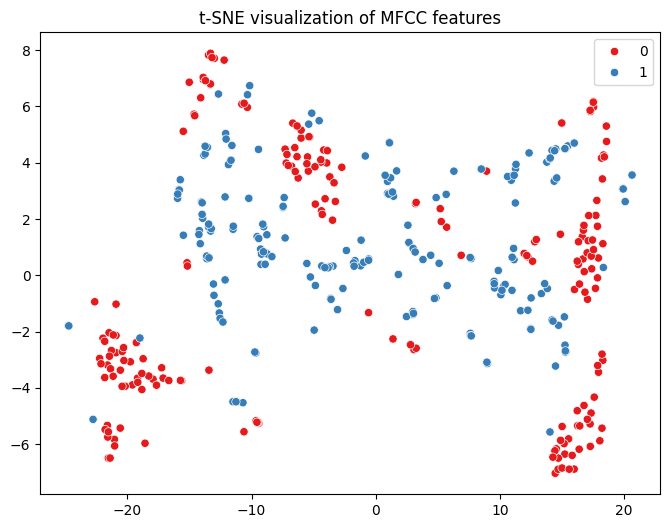

,"n_components n_components: int, default=2Dimension of the embedded space.",2
,"perplexity perplexity: float, default=30.0The perplexity is related to the number of nearest neighbors thatis used in other manifold learning algorithms. Larger datasetsusually require a larger perplexity. Consider selecting a valuebetween 5 and 50. Different values can result in significantlydifferent results. The perplexity must be less than the numberof samples.",50
,"early_exaggeration early_exaggeration: float, default=12.0Controls how tight natural clusters in the original space are inthe embedded space and how much space will be between them. Forlarger values, the space between natural clusters will be largerin the embedded space. Again, the choice of this parameter is notvery critical. If the cost function increases during initialoptimization, the early exaggeration factor or the learning ratemight be too high.",12.0
,"learning_rate learning_rate: float or ""auto"", default=""auto""The learning rate for t-SNE is usually in the range [10.0, 1000.0]. Ifthe learning rate is too high, the data may look like a 'ball' with anypoint approximately equidistant from its nearest neighbours. If thelearning rate is too low, most points may look compressed in a densecloud with few outliers. If the cost function gets stuck in a bad localminimum increasing the learning rate may help.Note that many other t-SNE implementations (bhtsne, FIt-SNE, openTSNE,etc.) use a definition of learning_rate that is 4 times smaller thanours. So our learning_rate=200 corresponds to learning_rate=800 inthose other implementations. The 'auto' option sets the learning_rateto `max(N / early_exaggeration / 4, 50)` where N is the sample size,following [4] and [5]... versionchanged:: 1.2 The default value changed to `""auto""`.",'auto'
,"max_iter max_iter: int, default=1000Maximum number of iterations for the optimization. Should be atleast 250... versionchanged:: 1.5 Parameter name changed from `n_iter` to `max_iter`.",1000
,"n_iter_without_progress n_iter_without_progress: int, default=300Maximum number of iterations without progress before we abort theoptimization, used after 250 initial iterations with earlyexaggeration. Note that progress is only checked every 50 iterations sothis value is rounded to the next multiple of 50... versionadded:: 0.17 parameter *n_iter_without_progress* to control stopping criteria.",300
,"min_grad_norm min_grad_norm: float, default=1e-7If the gradient norm is below this threshold, the optimization willbe stopped.",1e-07
,"metric metric: str or callable, default='euclidean'The metric to use when calculating distance between instances in afeature array. If metric is a string, it must be one of the optionsallowed by scipy.spatial.distance.pdist for its metric parameter, ora metric listed in pairwise.PAIRWISE_DISTANCE_FUNCTIONS.If metric is ""precomputed"", X is assumed to be a distance matrix.Alternatively, if metric is a callable function, it is called on eachpair of instances (rows) and the resulting value recorded. The callableshould take two arrays from X as input and return a value indicatingthe distance between them. The default is ""euclidean"" which isinterpreted as squared euclidean distance.",'euclidean'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function... versionadded:: 1.1",None
,"init init: {""random"", ""pca""} or ndarray of shape (n_samples, n_components), default=""pca""Initialization of embedding.PCA initialization cannot be used with precomputed distances and isusually more globally stable than random initialization... versionchanged:: 1.2 The default value changed to `""pca""`.",'pca'
,"verbose verbose: int, default=0Verbosity level.",0


In [147]:
analyze.tsne()

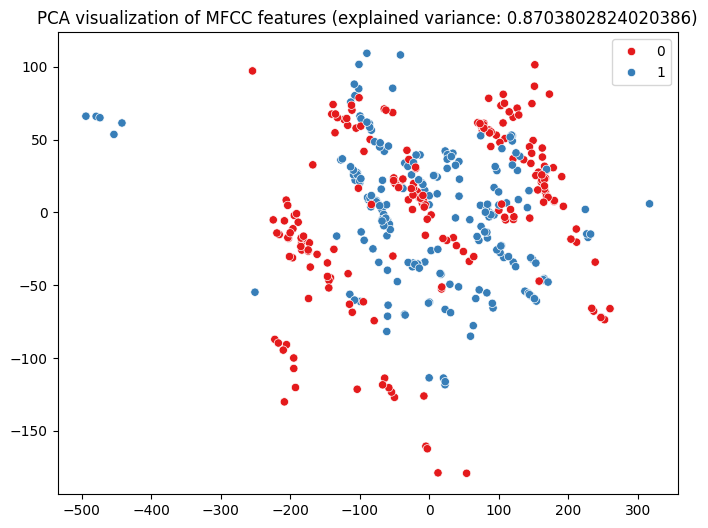

,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",2
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized SVD 

In [148]:
analyze.pca()

In [149]:
analyze.simple_fit_predict()

SVM (RBF): accuracy = 0.8875
SVM (linear): accuracy = 0.9375
SVM (poly): accuracy = 0.8500
Random Forest: accuracy = 0.9625
Logistic Regression: accuracy = 0.9375


### [Audio Spectrogram Transformer](https://huggingface.co/docs/transformers/model_doc/audio-spectrogram-transformer)

In [150]:
def count_parameters(model, trainable_only=True):
    if trainable_only:
        return sum(p.numel() for p in model.parameters() if p.requires_grad)
    else:
        return sum(p.numel() for p in model.parameters())

In [11]:
def get_inputs(wav, feature_extractor, sr, target_sr, max_len_sec):
    wav = torch.tensor(wav).float()
    if wav.ndim == 1:
        wav = wav.unsqueeze(0)
    if sr != target_sr:
        resampler = torchaudio.transforms.Resample(orig_freq=sr, new_freq=target_sr)
        wav = resampler(wav)
    target_len = int(target_sr * max_len_sec)
    if wav.shape[1] > target_len:
        wav = wav[:, :target_len]
    elif wav.shape[1] < target_len:
        pad = target_len - wav.shape[1]
        wav = nn.functional.pad(wav, (0, pad))
    return feature_extractor(wav.squeeze().numpy(), sampling_rate=target_sr, return_tensors='pt')

In [12]:
class AST(nn.Module):
    def __init__(self):
        super().__init__()
        self.name = 'MIT/ast-finetuned-audioset-10-10-0.4593'
        self.feature_extractor = ASTFeatureExtractor.from_pretrained(self.name)
        self.ast_model = ASTModel.from_pretrained(self.name)
        self.ast_model.eval()
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        self.ast_model = self.ast_model.to(self.device)

    def extract_ast_embedding(self, wav, sr, max_len_sec=5.0, target_sr=16000):
        inputs = get_inputs(wav, feature_extractor=self.feature_extractor, sr=sr, target_sr=target_sr, max_len_sec=max_len_sec)
        input_values = inputs['input_values'].to(self.device)
        with torch.no_grad():
            outputs = self.ast_model(input_values)
            embedding = outputs.last_hidden_state.mean(dim=1).cpu().numpy().squeeze()
        return embedding

    def extract_ast_embeddings(self, X, srs, max_len_sec=5.0, target_sr=16000):
        return np.array([self.extract_ast_embedding(wav, sr, max_len_sec, target_sr) for wav, sr in zip(X, srs)])

    def forward(self, x):
        return self.ast_model(x)

In [13]:
class AudioDataset(Dataset):
    def __init__(self, feature_extractor, wavs, labels, orig_srs, target_sr=16000, max_len_sec=5):
        self.wavs = wavs
        self.labels = labels
        self.srs = orig_srs
        self.target_sr = target_sr
        self.max_len_sec = max_len_sec
        self.feature_extractor = feature_extractor

    def __len__(self):
        return len(self.wavs)

    def __getitem__(self, idx):
        inputs = get_inputs(self.wavs[idx], feature_extractor=self.feature_extractor, sr=self.srs[idx], \
                            target_sr=self.target_sr, max_len_sec=self.max_len_sec)
        return inputs['input_values'].squeeze(0), torch.tensor(self.labels[idx], dtype=torch.long)

In [15]:
ast_model = AST()

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

ASTModel LOAD REPORT from: MIT/ast-finetuned-audioset-10-10-0.4593
Key                         | Status     |  | 
----------------------------+------------+--+-
classifier.dense.weight     | UNEXPECTED |  | 
classifier.dense.bias       | UNEXPECTED |  | 
classifier.layernorm.weight | UNEXPECTED |  | 
classifier.layernorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [136]:
print(count_parameters(ast_model))

86187264


In [20]:
def analyze_ast_model_1(ast_model=ast_model, analyze=analyze, max_len_sec=5.0):
    X_train = ast_model.extract_ast_embeddings(X=analyze.X_train, srs=analyze.sr_train, max_len_sec=max_len_sec)
    X_test = ast_model.extract_ast_embeddings(X=analyze.X_test, srs=analyze.sr_test, max_len_sec=max_len_sec)
    X = np.vstack([X_train, X_test])
    visualize_tsne(X=X, y=analyze.y_all, name='AST')
    visualize_pca(X=X, y=analyze.y_all, name='AST')
    simple_fit_predict(X_train=X_train, y_train=analyze.y_train, X_test=X_test, y_test=analyze.y_test)

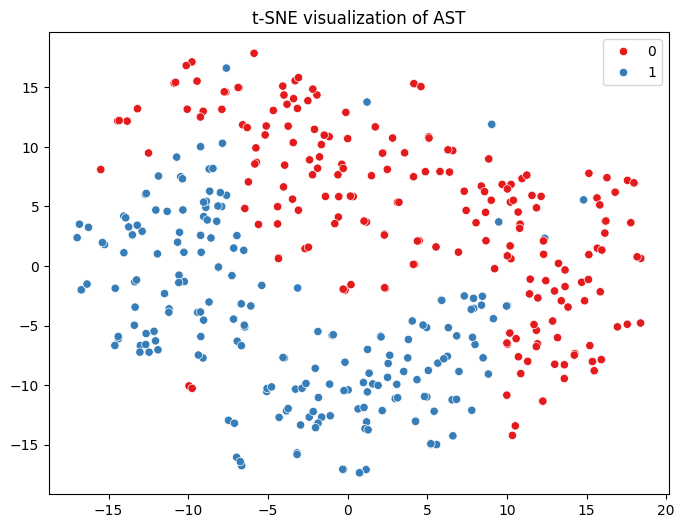

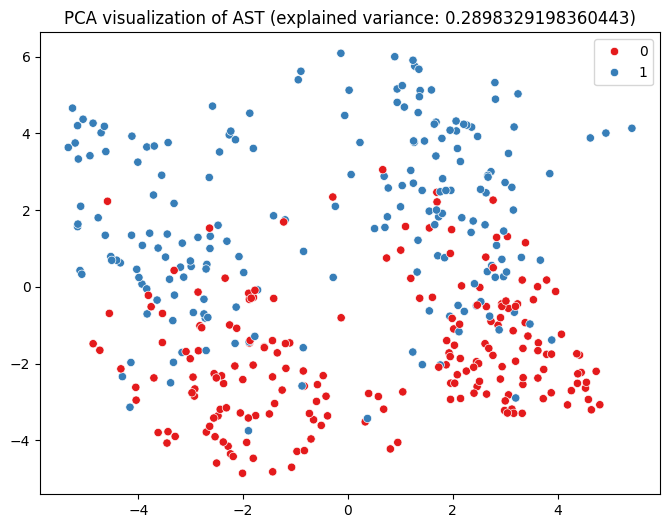

SVM (RBF): accuracy = 0.9625
SVM (linear): accuracy = 0.9750
SVM (poly): accuracy = 0.9625
Random Forest: accuracy = 0.9750
Logistic Regression: accuracy = 0.9750


In [156]:
analyze_ast_model_1()

In [21]:
def train(model, train_loader, test_loader, device, params, epochs, lr):
    optimizer = torch.optim.Adam(params, lr=lr)
    loss_fun = nn.CrossEntropyLoss()
    for epoch in tqdm(range(epochs)):
        model.train()
        total_loss = 0
        correct = 0
        for Xb, yb in tqdm(train_loader):
            Xb, yb = Xb.to(device), yb.to(device)
            optimizer.zero_grad()
            preds = model(Xb)
            correct += (preds.argmax(dim=1) == yb).sum().item()
            loss = loss_fun(preds, yb)
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * Xb.size(0)
        avg_loss = total_loss / len(train_loader.dataset)
        train_acc = correct / len(train_loader.dataset)

        model.eval()
        correct = 0
        with torch.no_grad():
            for Xb, yb in test_loader:
                Xb, yb = Xb.to(device), yb.to(device)
                preds = model(Xb).argmax(dim=1)
                correct += (preds == yb).sum().item()
        acc = correct / len(test_loader.dataset)
        print(f'Epoch {epoch+1} | Loss: {avg_loss:.6f} | Train acc: {train_acc:.6f} | Test acc: {acc:.6f}')

In [22]:
class ASTHeadClassifier(nn.Module):
    def __init__(self, ast_model, num_classes=2):
        super().__init__()
        self.ast = ast_model
        hidden_size = self.ast.ast_model.config.hidden_size
        self.head = nn.Sequential(
            nn.Linear(hidden_size, 256),
            nn.Tanh(),
            nn.Dropout(0.2),
            nn.Linear(256, num_classes)
        )
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    def forward(self, x):
        outputs = self.ast(x)
        means = outputs.last_hidden_state.mean(dim=1)
        return self.head(means)

    def train_and_report(self, epochs=20, lr=1e-3, is_ast_frozen=True):
        params = list(self.head.parameters())
        if is_ast_frozen:
            for param in self.ast.parameters():
                param.requires_grad = False
        else:
            for param in self.ast.parameters():
                param.requires_grad = True
            params += list(self.ast.parameters())
        train(model=self, train_loader=self.train_loader, test_loader=self.test_loader, device=self.device, params=params, epochs=epochs, lr=lr)

In [23]:
def set_loaders(model, X_train, y_train, sr_train, X_test, y_test, sr_test, batch_size=4, max_len_sec=5.0):
    model.train_dataset = AudioDataset(model.ast.feature_extractor, X_train, y_train, sr_train, max_len_sec=max_len_sec)
    model.test_dataset = AudioDataset(model.ast.feature_extractor, X_test, y_test, sr_test, max_len_sec=max_len_sec)
    model.train_loader = DataLoader(model.train_dataset, batch_size=batch_size, shuffle=True)
    model.test_loader = DataLoader(model.test_dataset, batch_size=batch_size, shuffle=False)

In [24]:
ast_head_model = ASTHeadClassifier(ast_model=ast_model)
ast_head_model.to(ast_model.device)
set_loaders(ast_head_model, X_train=analyze.X_train, y_train=analyze.y_train, sr_train=analyze.sr_train, \
            X_test=analyze.X_test, y_test=analyze.y_test, sr_test=analyze.sr_test)

In [177]:
ast_head_model.train_and_report()

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/80 [00:00<?, ?it/s]

Epoch 1 | Loss: 0.315030 | Train acc: 0.871875 | Test acc: 0.937500


  0%|          | 0/80 [00:00<?, ?it/s]

Epoch 2 | Loss: 0.097522 | Train acc: 0.971875 | Test acc: 0.950000


  0%|          | 0/80 [00:00<?, ?it/s]

Epoch 3 | Loss: 0.088260 | Train acc: 0.968750 | Test acc: 0.962500


  0%|          | 0/80 [00:00<?, ?it/s]

Epoch 4 | Loss: 0.071750 | Train acc: 0.962500 | Test acc: 0.625000


  0%|          | 0/80 [00:00<?, ?it/s]

Epoch 5 | Loss: 0.047338 | Train acc: 0.984375 | Test acc: 0.975000


  0%|          | 0/80 [00:00<?, ?it/s]

Epoch 6 | Loss: 0.052235 | Train acc: 0.981250 | Test acc: 0.975000


  0%|          | 0/80 [00:00<?, ?it/s]

Epoch 7 | Loss: 0.013310 | Train acc: 1.000000 | Test acc: 0.925000


  0%|          | 0/80 [00:00<?, ?it/s]

Epoch 8 | Loss: 0.026016 | Train acc: 0.987500 | Test acc: 0.962500


  0%|          | 0/80 [00:00<?, ?it/s]

Epoch 9 | Loss: 0.018538 | Train acc: 0.993750 | Test acc: 0.975000


  0%|          | 0/80 [00:00<?, ?it/s]

Epoch 10 | Loss: 0.021468 | Train acc: 0.993750 | Test acc: 0.962500


  0%|          | 0/80 [00:00<?, ?it/s]

Epoch 11 | Loss: 0.057282 | Train acc: 0.975000 | Test acc: 0.975000


  0%|          | 0/80 [00:00<?, ?it/s]

Epoch 12 | Loss: 0.008054 | Train acc: 1.000000 | Test acc: 0.975000


  0%|          | 0/80 [00:00<?, ?it/s]

Epoch 13 | Loss: 0.003068 | Train acc: 1.000000 | Test acc: 0.962500


  0%|          | 0/80 [00:00<?, ?it/s]

Epoch 14 | Loss: 0.047124 | Train acc: 0.981250 | Test acc: 0.962500


  0%|          | 0/80 [00:00<?, ?it/s]

Epoch 15 | Loss: 0.041552 | Train acc: 0.993750 | Test acc: 0.962500


  0%|          | 0/80 [00:00<?, ?it/s]

Epoch 16 | Loss: 0.017715 | Train acc: 0.993750 | Test acc: 0.962500


  0%|          | 0/80 [00:00<?, ?it/s]

Epoch 17 | Loss: 0.023743 | Train acc: 0.990625 | Test acc: 0.962500


  0%|          | 0/80 [00:00<?, ?it/s]

Epoch 18 | Loss: 0.001770 | Train acc: 1.000000 | Test acc: 0.962500


  0%|          | 0/80 [00:00<?, ?it/s]

Epoch 19 | Loss: 0.001231 | Train acc: 1.000000 | Test acc: 0.962500


  0%|          | 0/80 [00:00<?, ?it/s]

Epoch 20 | Loss: 0.000686 | Train acc: 1.000000 | Test acc: 0.975000


In [178]:
ast_head_model.train_and_report(is_ast_frozen=False, epochs=5, lr=1e-4)

  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/80 [00:00<?, ?it/s]

Epoch 1 | Loss: 1.353287 | Train acc: 0.887500 | Test acc: 0.962500


  0%|          | 0/80 [00:00<?, ?it/s]

Epoch 2 | Loss: 0.210278 | Train acc: 0.956250 | Test acc: 0.975000


  0%|          | 0/80 [00:00<?, ?it/s]

Epoch 3 | Loss: 0.078338 | Train acc: 0.981250 | Test acc: 0.987500


  0%|          | 0/80 [00:00<?, ?it/s]

Epoch 4 | Loss: 0.043193 | Train acc: 0.987500 | Test acc: 0.987500


  0%|          | 0/80 [00:00<?, ?it/s]

Epoch 5 | Loss: 0.023447 | Train acc: 0.990625 | Test acc: 0.987500


In [25]:
def analyze_ast_head_model_1(ast_head_model=ast_head_model, analyze=analyze, max_len_sec=5.0):
    X_train = ast_head_model.ast.extract_ast_embeddings(X=analyze.X_train, srs=analyze.sr_train, max_len_sec=max_len_sec)
    X_test = ast_head_model.ast.extract_ast_embeddings(X=analyze.X_test, srs=analyze.sr_test, max_len_sec=max_len_sec)
    X = np.vstack([X_train, X_test])
    visualize_tsne(X=X, y=analyze.y_all, name='AST')
    visualize_pca(X=X, y=analyze.y_all, name='AST')
    simple_fit_predict(X_train=X_train, y_train=analyze.y_train, X_test=X_test, y_test=analyze.y_test)

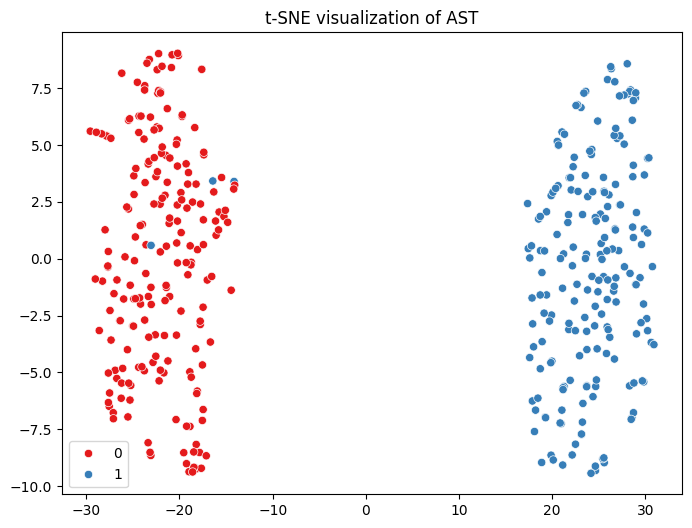

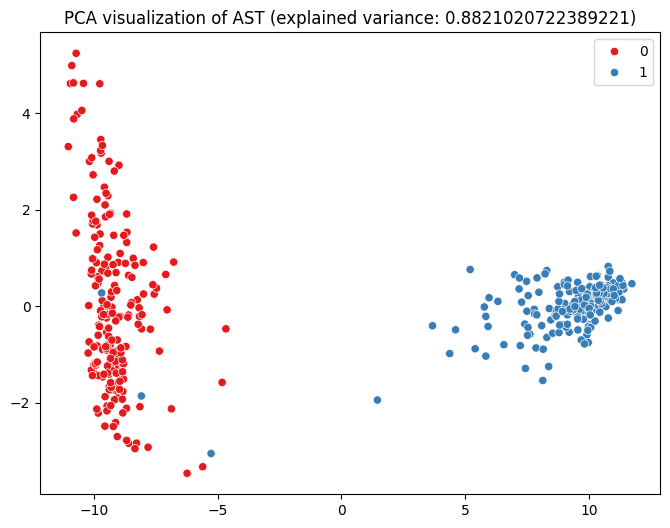

SVM (RBF): accuracy = 0.9875
SVM (linear): accuracy = 0.9875
SVM (poly): accuracy = 0.9875
Random Forest: accuracy = 0.9875
Logistic Regression: accuracy = 0.9875


In [180]:
analyze_ast_head_model_1()

In [189]:
def plot_spectrogram(wav, sr, title):
    D = librosa.stft(wav)
    S_db = librosa.amplitude_to_db(np.abs(D), ref=np.max)
    plt.figure().set_figwidth(12)
    librosa.display.specshow(S_db, sr=sr, x_axis="time", y_axis="hz")
    plt.colorbar()
    plt.title(title)

In [190]:
def plot_spectrograms(model, analyze):
    test_embeddings = model.ast.extract_ast_embeddings(X=analyze.X_test, srs=analyze.sr_test)
    dist_matrix = squareform(pdist(test_embeddings, metric='euclidean'))
    np.fill_diagonal(dist_matrix, np.inf)
    min_idx = np.unravel_index(np.argmin(dist_matrix), dist_matrix.shape)
    np.fill_diagonal(dist_matrix, -np.inf)
    max_idx = np.unravel_index(np.argmax(dist_matrix), dist_matrix.shape)
    print(f'The farthest pair: {dist_matrix[max_idx]}')
    print(f'The nearest pair: {dist_matrix[min_idx]}')
    srs = analyze.sr_test
    plot_spectrogram(analyze.X_test[max_idx[0]], srs[max_idx[0]], 'First element of the farthest pair')
    plot_spectrogram(analyze.X_test[max_idx[1]], srs[max_idx[1]], 'Second element of the farthest pair')
    plot_spectrogram(analyze.X_test[min_idx[0]], srs[min_idx[0]], 'First element of the nearest pair')
    plot_spectrogram(analyze.X_test[min_idx[1]], srs[min_idx[1]], 'Second element of the nearest pair')

The farthest pair: 23.36599696227749
The nearest pair: 1.286568019223815


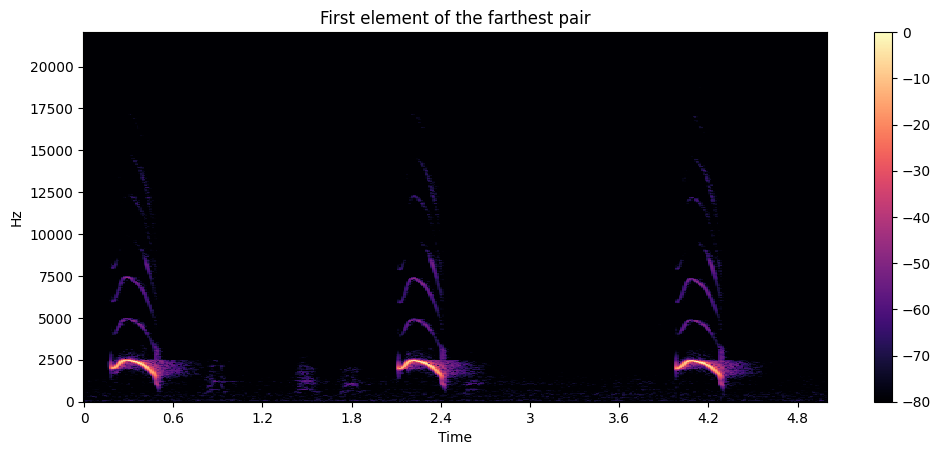

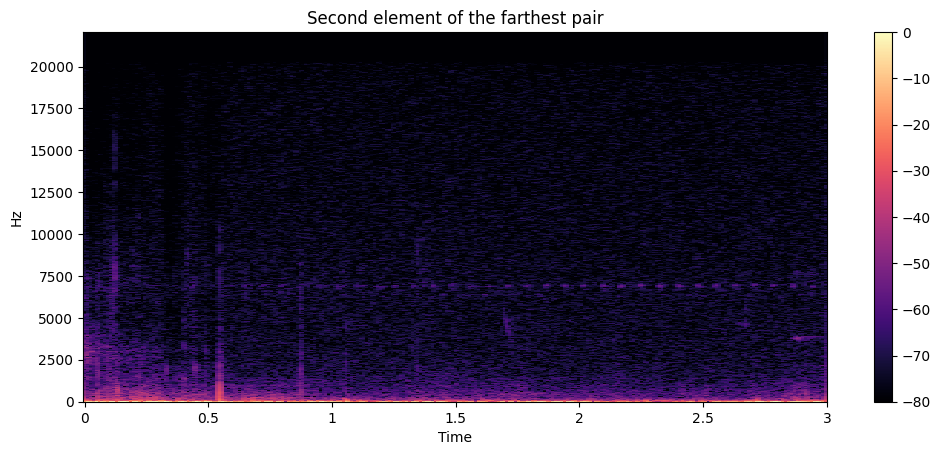

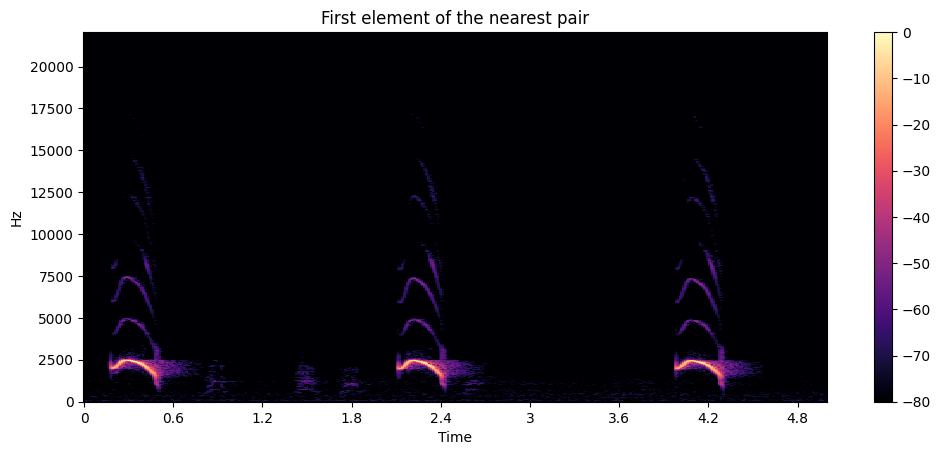

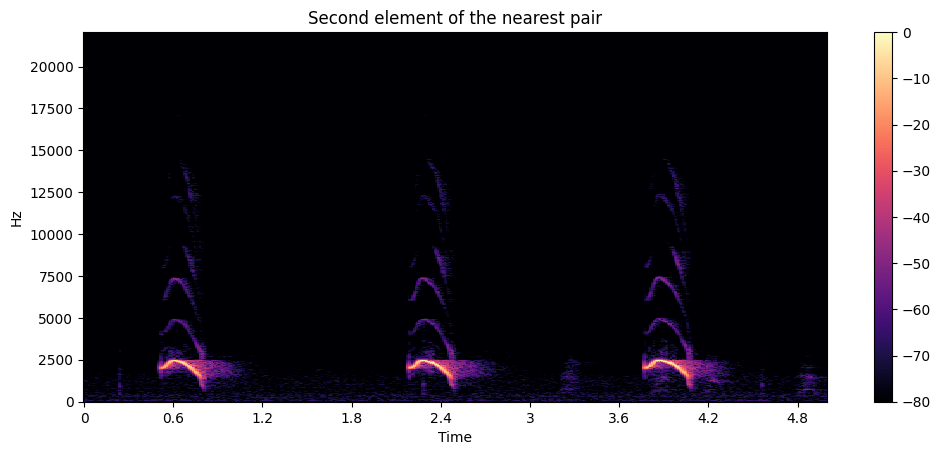

In [191]:
plot_spectrograms(ast_head_model, analyze)

### Russian Emotional Speech Dialogues

[https://github.com/aniemore/Aniemore](https://github.com/aniemore/Aniemore) </br>

[https://huggingface.co/datasets/Aniemore/resd](https://huggingface.co/datasets/Aniemore/resd)

In [26]:
def load_huggingface_dataset_2(tag):
    dataset = load_dataset(tag)
    X_train = []
    y_train = []
    sr_train = []
    X_test = []
    y_test = []
    sr_test = []
    le = LabelEncoder()
    for sample in dataset['train']:
        sr_train.append(sample['speech']['sampling_rate'])
        X_train.append(sample['speech']['array'])
        y_train.append(sample['emotion'])
    for sample in dataset['test']:
        sr_test.append(sample['speech']['sampling_rate'])
        X_test.append(sample['speech']['array'])
        y_test.append(sample['emotion'])
    return X_train, le.fit_transform(y_train), sr_train, X_test, le.fit_transform(y_test), sr_test

In [28]:
analyze_1 = HuggingfaceDatasetAnalyze(tag='Aniemore/resd', load_huggingface_dataset=load_huggingface_dataset_2)

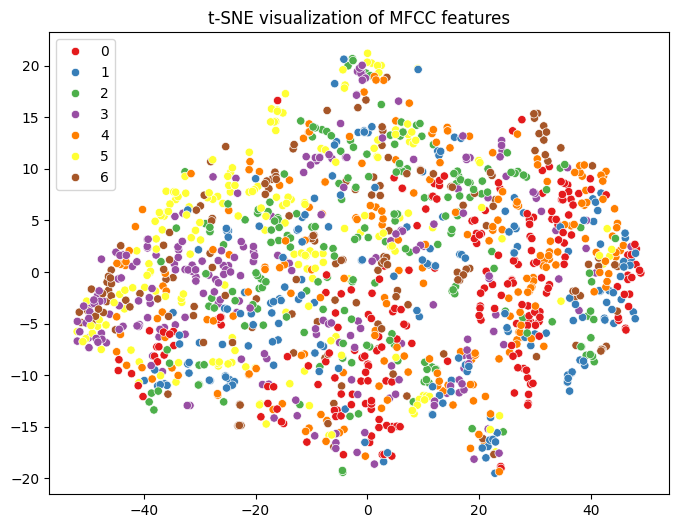

,"n_components n_components: int, default=2Dimension of the embedded space.",2
,"perplexity perplexity: float, default=30.0The perplexity is related to the number of nearest neighbors thatis used in other manifold learning algorithms. Larger datasetsusually require a larger perplexity. Consider selecting a valuebetween 5 and 50. Different values can result in significantlydifferent results. The perplexity must be less than the numberof samples.",50
,"early_exaggeration early_exaggeration: float, default=12.0Controls how tight natural clusters in the original space are inthe embedded space and how much space will be between them. Forlarger values, the space between natural clusters will be largerin the embedded space. Again, the choice of this parameter is notvery critical. If the cost function increases during initialoptimization, the early exaggeration factor or the learning ratemight be too high.",12.0
,"learning_rate learning_rate: float or ""auto"", default=""auto""The learning rate for t-SNE is usually in the range [10.0, 1000.0]. Ifthe learning rate is too high, the data may look like a 'ball' with anypoint approximately equidistant from its nearest neighbours. If thelearning rate is too low, most points may look compressed in a densecloud with few outliers. If the cost function gets stuck in a bad localminimum increasing the learning rate may help.Note that many other t-SNE implementations (bhtsne, FIt-SNE, openTSNE,etc.) use a definition of learning_rate that is 4 times smaller thanours. So our learning_rate=200 corresponds to learning_rate=800 inthose other implementations. The 'auto' option sets the learning_rateto `max(N / early_exaggeration / 4, 50)` where N is the sample size,following [4] and [5]... versionchanged:: 1.2 The default value changed to `""auto""`.",'auto'
,"max_iter max_iter: int, default=1000Maximum number of iterations for the optimization. Should be atleast 250... versionchanged:: 1.5 Parameter name changed from `n_iter` to `max_iter`.",1000
,"n_iter_without_progress n_iter_without_progress: int, default=300Maximum number of iterations without progress before we abort theoptimization, used after 250 initial iterations with earlyexaggeration. Note that progress is only checked every 50 iterations sothis value is rounded to the next multiple of 50... versionadded:: 0.17 parameter *n_iter_without_progress* to control stopping criteria.",300
,"min_grad_norm min_grad_norm: float, default=1e-7If the gradient norm is below this threshold, the optimization willbe stopped.",1e-07
,"metric metric: str or callable, default='euclidean'The metric to use when calculating distance between instances in afeature array. If metric is a string, it must be one of the optionsallowed by scipy.spatial.distance.pdist for its metric parameter, ora metric listed in pairwise.PAIRWISE_DISTANCE_FUNCTIONS.If metric is ""precomputed"", X is assumed to be a distance matrix.Alternatively, if metric is a callable function, it is called on eachpair of instances (rows) and the resulting value recorded. The callableshould take two arrays from X as input and return a value indicatingthe distance between them. The default is ""euclidean"" which isinterpreted as squared euclidean distance.",'euclidean'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function... versionadded:: 1.1",None
,"init init: {""random"", ""pca""} or ndarray of shape (n_samples, n_components), default=""pca""Initialization of embedding.PCA initialization cannot be used with precomputed distances and isusually more globally stable than random initialization... versionchanged:: 1.2 The default value changed to `""pca""`.",'pca'
,"verbose verbose: int, default=0Verbosity level.",0


In [29]:
analyze_1.tsne()

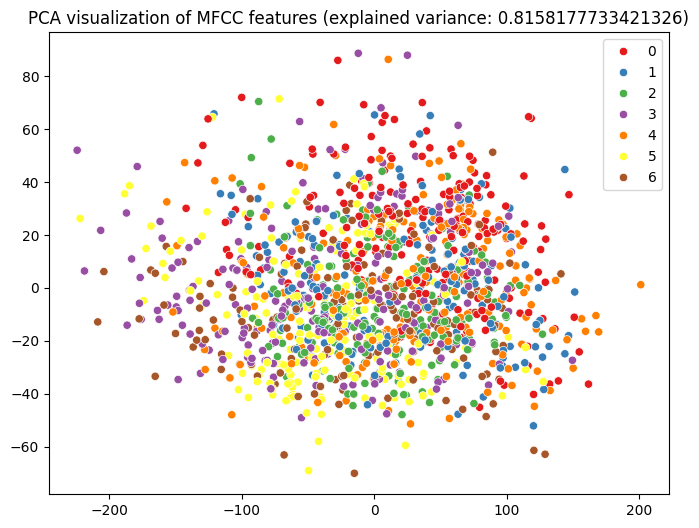

,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",2
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized SVD 

In [30]:
analyze_1.pca()

In [31]:
analyze_1.simple_fit_predict()

SVM (RBF): accuracy = 0.2857
SVM (linear): accuracy = 0.4857
SVM (poly): accuracy = 0.2893
Random Forest: accuracy = 0.6357
Logistic Regression: accuracy = 0.4250


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 10000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=10000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [32]:
ast_model_1 = AST()

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

ASTModel LOAD REPORT from: MIT/ast-finetuned-audioset-10-10-0.4593
Key                         | Status     |  | 
----------------------------+------------+--+-
classifier.dense.weight     | UNEXPECTED |  | 
classifier.dense.bias       | UNEXPECTED |  | 
classifier.layernorm.weight | UNEXPECTED |  | 
classifier.layernorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


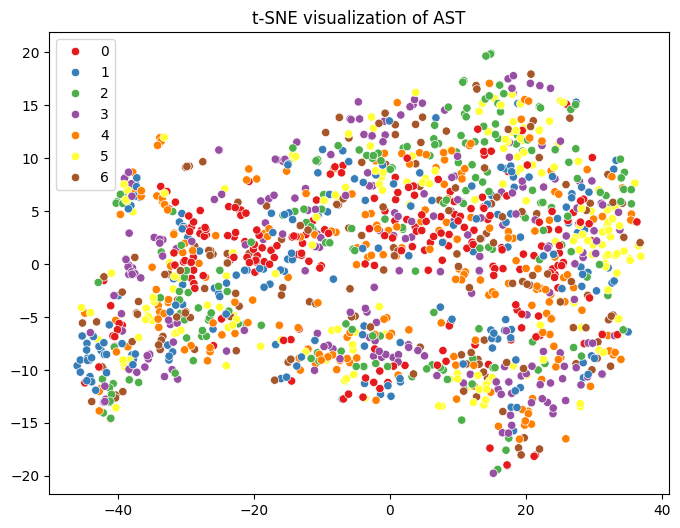

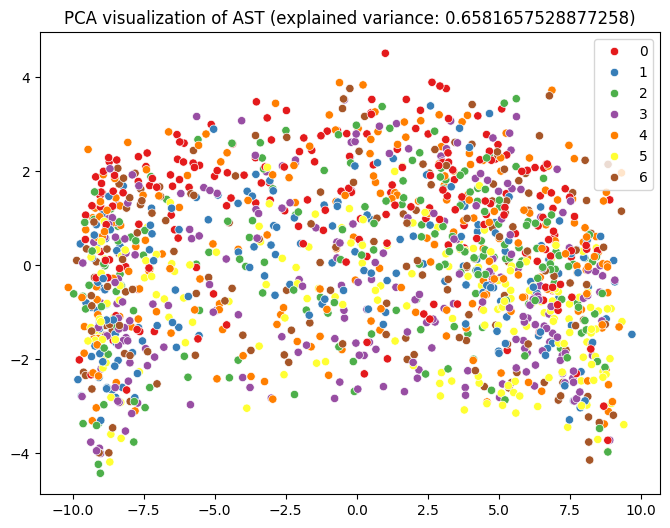

SVM (RBF): accuracy = 0.3679
SVM (linear): accuracy = 0.5143
SVM (poly): accuracy = 0.4000
Random Forest: accuracy = 0.4571
Logistic Regression: accuracy = 0.5250


In [33]:
analyze_ast_model_1(ast_model=ast_model_1, analyze=analyze_1, max_len_sec=20.0)

In [34]:
ast_head_model_1 = ASTHeadClassifier(ast_model=ast_model_1, num_classes=7)
ast_head_model_1.to(ast_model_1.device)
set_loaders(ast_head_model_1, X_train=analyze_1.X_train, y_train=analyze_1.y_train, sr_train=analyze_1.sr_train, \
            X_test=analyze_1.X_test, y_test=analyze_1.y_test, sr_test=analyze_1.sr_test, max_len_sec=12.0)

In [35]:
ast_head_model_1.train_and_report()

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/279 [00:00<?, ?it/s]

Epoch 1 | Loss: 2.000941 | Train acc: 0.180108 | Test acc: 0.221429


  0%|          | 0/279 [00:00<?, ?it/s]

Epoch 2 | Loss: 1.893830 | Train acc: 0.225806 | Test acc: 0.289286


  0%|          | 0/279 [00:00<?, ?it/s]

Epoch 3 | Loss: 1.848743 | Train acc: 0.260753 | Test acc: 0.292857


  0%|          | 0/279 [00:00<?, ?it/s]

Epoch 4 | Loss: 1.793817 | Train acc: 0.294803 | Test acc: 0.278571


  0%|          | 0/279 [00:00<?, ?it/s]

Epoch 5 | Loss: 1.735401 | Train acc: 0.313620 | Test acc: 0.292857


  0%|          | 0/279 [00:00<?, ?it/s]

Epoch 6 | Loss: 1.717428 | Train acc: 0.316308 | Test acc: 0.389286


  0%|          | 0/279 [00:00<?, ?it/s]

Epoch 7 | Loss: 1.700138 | Train acc: 0.331541 | Test acc: 0.296429


  0%|          | 0/279 [00:00<?, ?it/s]

Epoch 8 | Loss: 1.707232 | Train acc: 0.321685 | Test acc: 0.360714


  0%|          | 0/279 [00:00<?, ?it/s]

Epoch 9 | Loss: 1.697954 | Train acc: 0.332437 | Test acc: 0.328571


  0%|          | 0/279 [00:00<?, ?it/s]

Epoch 10 | Loss: 1.647616 | Train acc: 0.373656 | Test acc: 0.339286


  0%|          | 0/279 [00:00<?, ?it/s]

Epoch 11 | Loss: 1.655647 | Train acc: 0.351254 | Test acc: 0.317857


  0%|          | 0/279 [00:00<?, ?it/s]

Epoch 12 | Loss: 1.640770 | Train acc: 0.364695 | Test acc: 0.371429


  0%|          | 0/279 [00:00<?, ?it/s]

Epoch 13 | Loss: 1.612110 | Train acc: 0.384409 | Test acc: 0.332143


  0%|          | 0/279 [00:00<?, ?it/s]

Epoch 14 | Loss: 1.629222 | Train acc: 0.381720 | Test acc: 0.403571


  0%|          | 0/279 [00:00<?, ?it/s]

Epoch 15 | Loss: 1.623155 | Train acc: 0.391577 | Test acc: 0.303571


  0%|          | 0/279 [00:00<?, ?it/s]

Epoch 16 | Loss: 1.556332 | Train acc: 0.411290 | Test acc: 0.350000


  0%|          | 0/279 [00:00<?, ?it/s]

Epoch 17 | Loss: 1.548858 | Train acc: 0.398746 | Test acc: 0.335714


  0%|          | 0/279 [00:00<?, ?it/s]

Epoch 18 | Loss: 1.536512 | Train acc: 0.413978 | Test acc: 0.421429


  0%|          | 0/279 [00:00<?, ?it/s]

Epoch 19 | Loss: 1.504179 | Train acc: 0.438172 | Test acc: 0.325000


  0%|          | 0/279 [00:00<?, ?it/s]

Epoch 20 | Loss: 1.476003 | Train acc: 0.456989 | Test acc: 0.417857


In [36]:
ast_head_model_1.train_and_report(is_ast_frozen=False, epochs=5, lr=1e-5)

  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/279 [00:00<?, ?it/s]

Epoch 1 | Loss: 1.875897 | Train acc: 0.302867 | Test acc: 0.400000


  0%|          | 0/279 [00:00<?, ?it/s]

Epoch 2 | Loss: 1.529109 | Train acc: 0.454301 | Test acc: 0.400000


  0%|          | 0/279 [00:00<?, ?it/s]

Epoch 3 | Loss: 1.274518 | Train acc: 0.535842 | Test acc: 0.392857


  0%|          | 0/279 [00:00<?, ?it/s]

Epoch 4 | Loss: 1.048262 | Train acc: 0.611111 | Test acc: 0.396429


  0%|          | 0/279 [00:00<?, ?it/s]

Epoch 5 | Loss: 0.886503 | Train acc: 0.683692 | Test acc: 0.475000


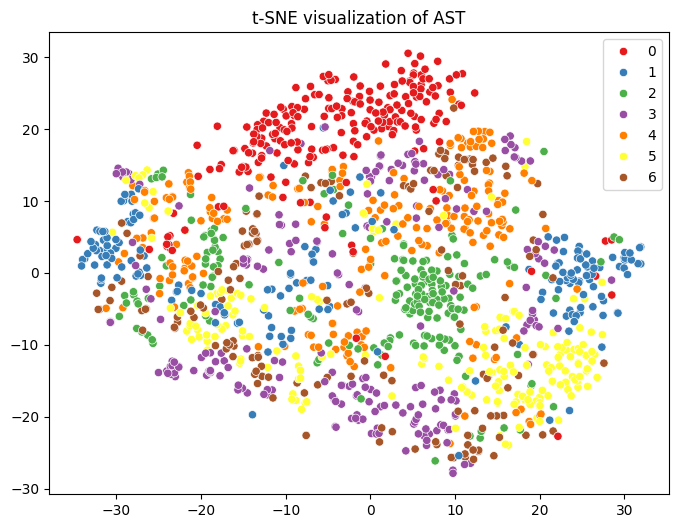

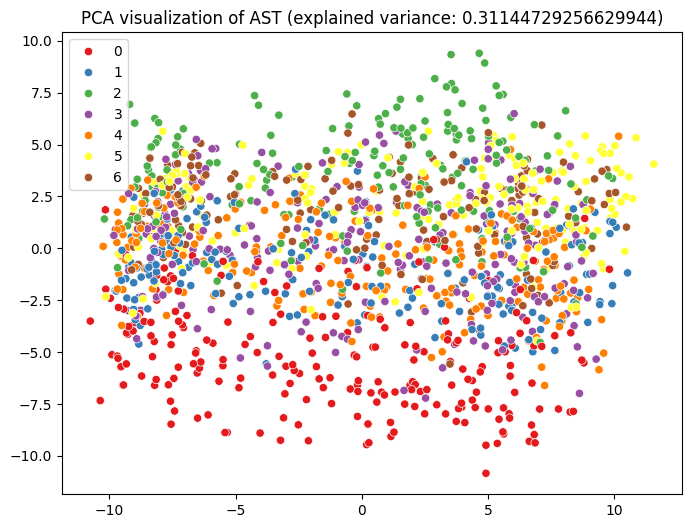

SVM (RBF): accuracy = 0.5857
SVM (linear): accuracy = 0.5750
SVM (poly): accuracy = 0.5893
Random Forest: accuracy = 0.5857
Logistic Regression: accuracy = 0.5821


In [37]:
analyze_ast_model_1(ast_model=ast_model_1, analyze=analyze_1, max_len_sec=20.0)

In [38]:
torch.save(ast_head_model_1.state_dict(), 'ast_head_epoch5_0475.pth')

In [39]:
ast_head_model_1.train_and_report(is_ast_frozen=False, epochs=1, lr=1e-5)

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/279 [00:00<?, ?it/s]

Epoch 1 | Loss: 0.647154 | Train acc: 0.771505 | Test acc: 0.457143
